# 🧠 Parkinson's Disease Detection
## Notebook 3: Model Training & Evaluation

**Goal:** Train multiple classifiers and compare them — focusing on **Recall** as the primary metric.

> 🔬 **Why Recall?** Missing a sick patient (False Negative) is far more harmful than a false alarm. In medical AI, recall is king.

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)

plt.style.use('seaborn-v0_8-whitegrid')
print('Libraries loaded ✅')

Libraries loaded ✅


In [31]:
with open('../results/preprocessed_data.pkl', 'rb') as f:
    data = pickle.load(f)

X_train        = data['X_train']
X_test         = data['X_test']
y_train        = data['y_train']
y_test         = data['y_test']
X_train_scaled = data['X_train_scaled']
X_test_scaled  = data['X_test_scaled']
feature_names  = data['feature_names']

print(f'Training: {X_train_scaled.shape}, Testing: {X_test_scaled.shape}')
print('Data loaded ✅')

Training: (156, 22), Testing: (39, 22)
Data loaded ✅


In [32]:
def evaluate_model(name, model, X_test_scaled, y_test):
    y_pred = model.predict(X_test_scaled)

    try:
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
        auc = roc_auc_score(y_test, y_prob)
    except:
        auc = None

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)

    print(f'\n{"="*50}')
    print(f'  {name}')
    print(f'{"="*50}')
    print(f'  Accuracy:  {acc:.4f}')
    print(f'  Precision: {prec:.4f}')
    print(f'  Recall:    {rec:.4f}   ← Most important!')
    print(f'  F1 Score:  {f1:.4f}')
    if auc:
        print(f'  ROC-AUC:   {auc:.4f}')
    print()
    print(classification_report(y_test, y_pred,
                                 target_names=['Healthy', "Parkinson's"]))

    # Confusion matrix plot
    cm = confusion_matrix(y_test, y_pred)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
                xticklabels=['Healthy', 'PD'],
                yticklabels=['Healthy', 'PD'],
                ax=axes[0], linewidths=2)
    axes[0].set_title(f'Confusion Matrix: {name}', fontweight='bold')
    axes[0].set_ylabel('Actual')
    axes[0].set_xlabel('Predicted')

    metrics = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1}
    if auc:
        metrics['AUC'] = auc
    colors = ['#3498DB', '#2ECC71', '#E74C3C', '#F39C12', '#9B59B6']
    bars = axes[1].bar(metrics.keys(), metrics.values(),
                        color=colors[:len(metrics)], edgecolor='white',
                        linewidth=2, alpha=0.85)
    axes[1].set_ylim(0, 1.15)
    axes[1].set_title(f'Performance Metrics: {name}', fontweight='bold')
    axes[1].set_ylabel('Score')
    for bar, val in zip(bars, metrics.values()):
        axes[1].text(bar.get_x() + bar.get_width()/2.,
                     bar.get_height() + 0.02,
                     f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')

    plt.tight_layout()
    safe_name = name.replace(' ', '_').replace('(', '').replace(')', '')
    plt.savefig(f'../results/cm_{safe_name}.png', dpi=120, bbox_inches='tight')
    plt.show()

    return {
        'Model': name,
        'Accuracy':  round(acc,  4),
        'Precision': round(prec, 4),
        'Recall':    round(rec,  4),
        'F1':        round(f1,   4),
        'ROC-AUC':   round(auc,  4) if auc else 'N/A'
    }

results = []
trained_models = {}
print('Evaluation function ready ✅')

Evaluation function ready ✅


## 5.2 Logistic Regression (Baseline)


  Logistic Regression
  Accuracy:  0.9231
  Precision: 0.9333
  Recall:    0.9655   ← Most important!
  F1 Score:  0.9492
  ROC-AUC:   0.9241

              precision    recall  f1-score   support

     Healthy       0.89      0.80      0.84        10
 Parkinson's       0.93      0.97      0.95        29

    accuracy                           0.92        39
   macro avg       0.91      0.88      0.90        39
weighted avg       0.92      0.92      0.92        39



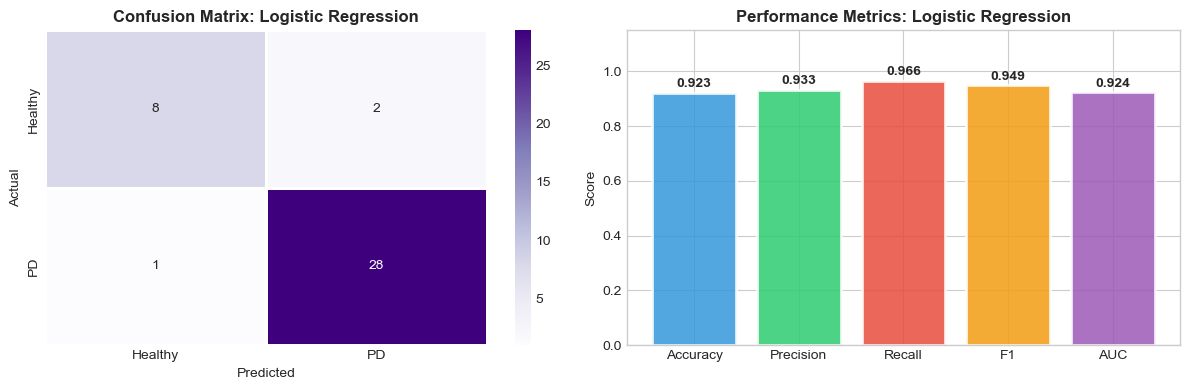

In [33]:
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)
trained_models['Logistic Regression'] = lr
results.append(evaluate_model('Logistic Regression', lr, X_test_scaled, y_test))

## 5.3 SVM with RBF Kernel
> SVM works especially well for **small datasets with many features** — exactly this dataset!


  SVM (RBF Kernel)
  Accuracy:  0.9231
  Precision: 0.9062
  Recall:    1.0000   ← Most important!
  F1 Score:  0.9508
  ROC-AUC:   0.9552

              precision    recall  f1-score   support

     Healthy       1.00      0.70      0.82        10
 Parkinson's       0.91      1.00      0.95        29

    accuracy                           0.92        39
   macro avg       0.95      0.85      0.89        39
weighted avg       0.93      0.92      0.92        39



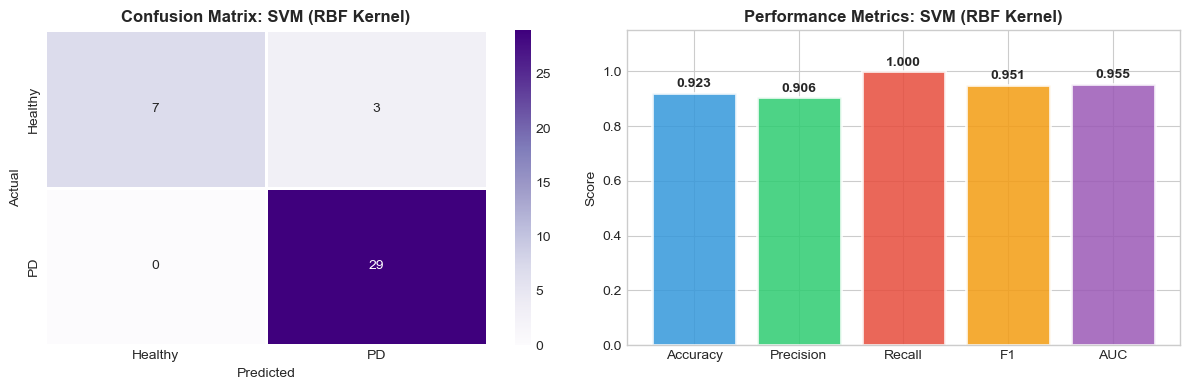

In [34]:
svm = SVC(kernel='rbf', probability=True, random_state=42)
svm.fit(X_train_scaled, y_train)
trained_models['SVM (RBF Kernel)'] = svm
results.append(evaluate_model('SVM (RBF Kernel)', svm, X_test_scaled, y_test))

## 5.4 Random Forest


  Random Forest
  Accuracy:  0.9231
  Precision: 0.9333
  Recall:    0.9655   ← Most important!
  F1 Score:  0.9492
  ROC-AUC:   0.9621

              precision    recall  f1-score   support

     Healthy       0.89      0.80      0.84        10
 Parkinson's       0.93      0.97      0.95        29

    accuracy                           0.92        39
   macro avg       0.91      0.88      0.90        39
weighted avg       0.92      0.92      0.92        39



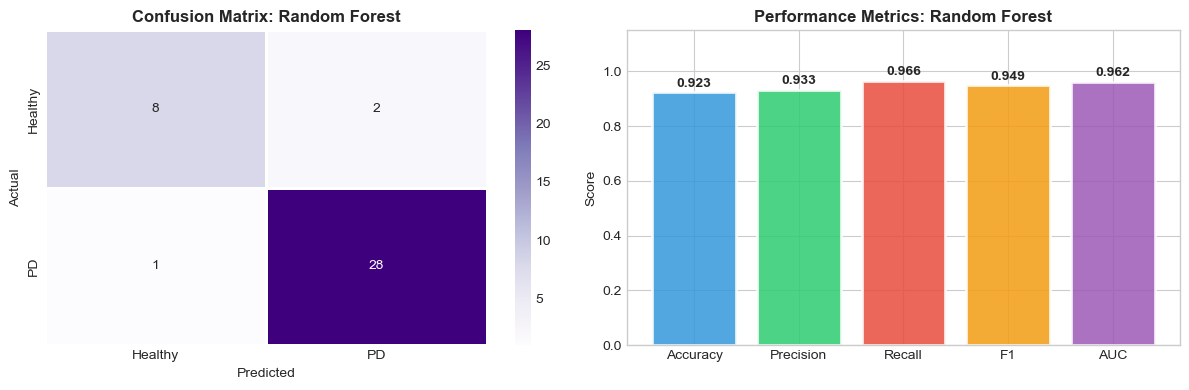

In [35]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
trained_models['Random Forest'] = rf
results.append(evaluate_model('Random Forest', rf, X_test_scaled, y_test))

## 5.5 XGBoost


  XGBoost
  Accuracy:  0.9231
  Precision: 0.9333
  Recall:    0.9655   ← Most important!
  F1 Score:  0.9492
  ROC-AUC:   0.9759

              precision    recall  f1-score   support

     Healthy       0.89      0.80      0.84        10
 Parkinson's       0.93      0.97      0.95        29

    accuracy                           0.92        39
   macro avg       0.91      0.88      0.90        39
weighted avg       0.92      0.92      0.92        39



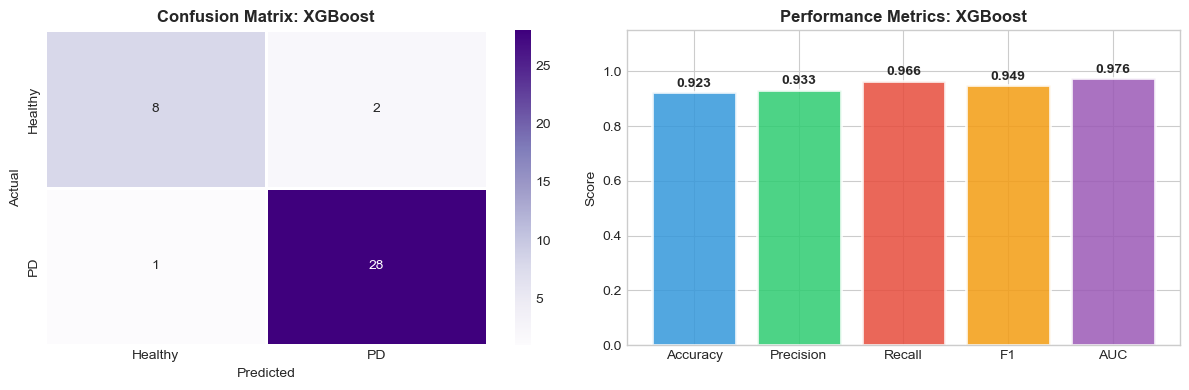

In [36]:
xgb = XGBClassifier(n_estimators=100, random_state=42,
                     eval_metric='logloss', verbosity=0)
xgb.fit(X_train_scaled, y_train)
trained_models['XGBoost'] = xgb
results.append(evaluate_model('XGBoost', xgb, X_test_scaled, y_test))


  XGBoost
  Accuracy:  0.9231
  Precision: 0.9333
  Recall:    0.9655   ← Most important!
  F1 Score:  0.9492
  ROC-AUC:   0.9759

              precision    recall  f1-score   support

     Healthy       0.89      0.80      0.84        10
 Parkinson's       0.93      0.97      0.95        29

    accuracy                           0.92        39
   macro avg       0.91      0.88      0.90        39
weighted avg       0.92      0.92      0.92        39



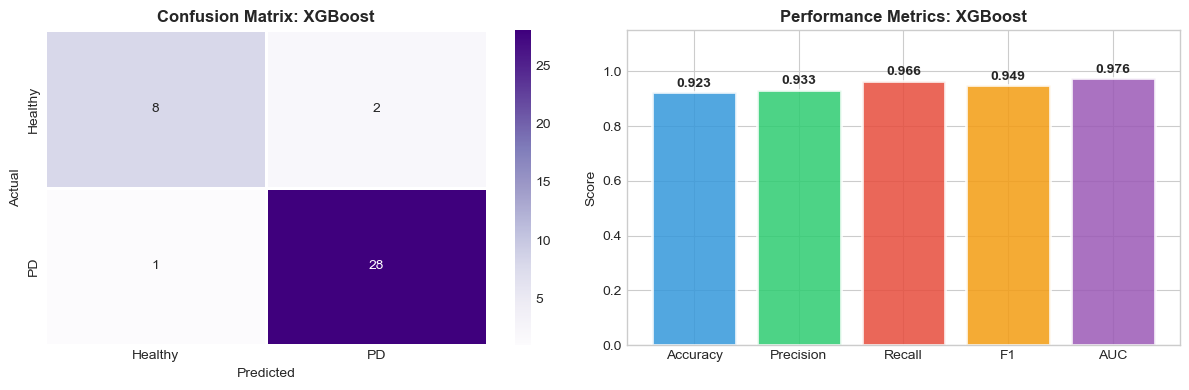

In [37]:
xgb = XGBClassifier(n_estimators=100, random_state=42,
                     eval_metric='logloss', verbosity=0)
xgb.fit(X_train_scaled, y_train)
trained_models['XGBoost'] = xgb
results.append(evaluate_model('XGBoost', xgb, X_test_scaled, y_test))

## 5.6 K-Nearest Neighbors


  KNN
  Accuracy:  0.9231
  Precision: 0.9333
  Recall:    0.9655   ← Most important!
  F1 Score:  0.9492
  ROC-AUC:   0.9638

              precision    recall  f1-score   support

     Healthy       0.89      0.80      0.84        10
 Parkinson's       0.93      0.97      0.95        29

    accuracy                           0.92        39
   macro avg       0.91      0.88      0.90        39
weighted avg       0.92      0.92      0.92        39



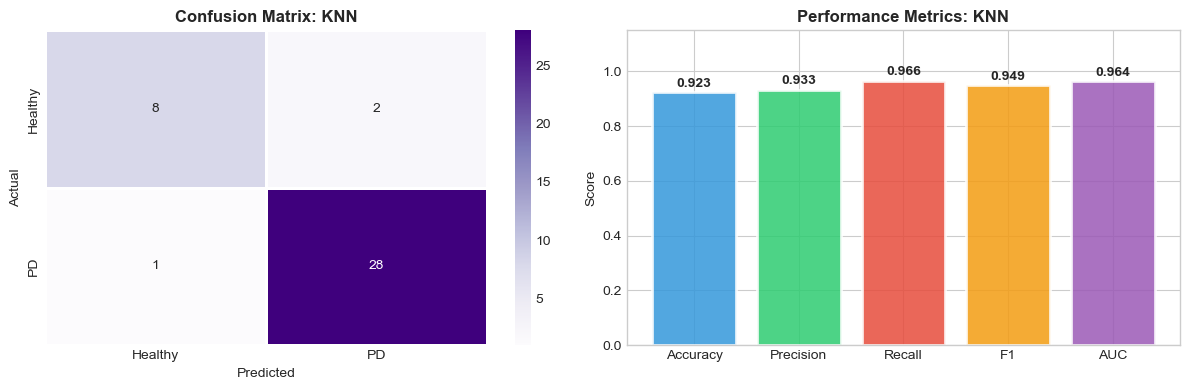

In [38]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
trained_models['KNN'] = knn
results.append(evaluate_model('KNN', knn, X_test_scaled, y_test))

## 5.7 Decision Tree


  Decision Tree
  Accuracy:  0.8462
  Precision: 0.8966
  Recall:    0.8966   ← Most important!
  F1 Score:  0.8966
  ROC-AUC:   0.7983

              precision    recall  f1-score   support

     Healthy       0.70      0.70      0.70        10
 Parkinson's       0.90      0.90      0.90        29

    accuracy                           0.85        39
   macro avg       0.80      0.80      0.80        39
weighted avg       0.85      0.85      0.85        39



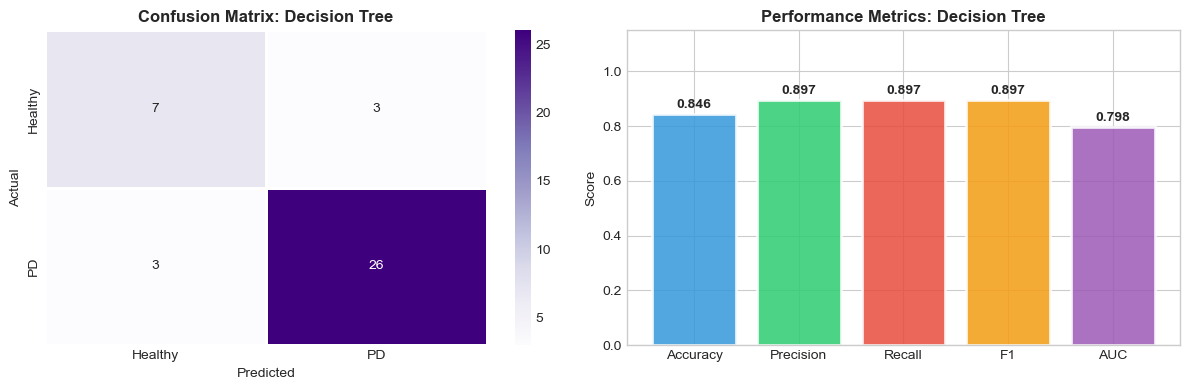

In [39]:
dt = DecisionTreeClassifier(random_state=42, max_depth=5)
dt.fit(X_train_scaled, y_train)
trained_models['Decision Tree'] = dt
results.append(evaluate_model('Decision Tree', dt, X_test_scaled, y_test))

## 5.8 Naive Bayes


  Naive Bayes
  Accuracy:  0.6667
  Precision: 1.0000
  Recall:    0.5517   ← Most important!
  F1 Score:  0.7111
  ROC-AUC:   0.8655

              precision    recall  f1-score   support

     Healthy       0.43      1.00      0.61        10
 Parkinson's       1.00      0.55      0.71        29

    accuracy                           0.67        39
   macro avg       0.72      0.78      0.66        39
weighted avg       0.86      0.67      0.68        39



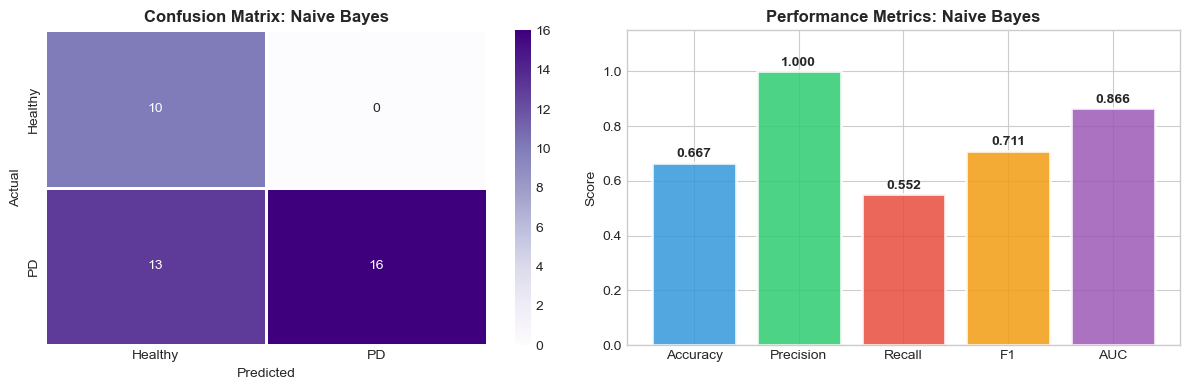

In [40]:
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)
trained_models['Naive Bayes'] = nb
results.append(evaluate_model('Naive Bayes', nb, X_test_scaled, y_test))

## 5.9 Model Comparison Table

In [41]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Recall', ascending=False)

print('=' * 70)
print('MODEL COMPARISON — Sorted by Recall (Most Important Metric)')
print('=' * 70)
print(results_df.to_string(index=False))

results_df.to_csv('../results/model_comparison.csv', index=False)
print('\n✅ Results saved to ../results/model_comparison.csv')

MODEL COMPARISON — Sorted by Recall (Most Important Metric)
              Model  Accuracy  Precision  Recall     F1  ROC-AUC
   SVM (RBF Kernel)    0.9231     0.9062  1.0000 0.9508   0.9552
Logistic Regression    0.9231     0.9333  0.9655 0.9492   0.9241
      Random Forest    0.9231     0.9333  0.9655 0.9492   0.9621
            XGBoost    0.9231     0.9333  0.9655 0.9492   0.9759
            XGBoost    0.9231     0.9333  0.9655 0.9492   0.9759
                KNN    0.9231     0.9333  0.9655 0.9492   0.9638
      Decision Tree    0.8462     0.8966  0.8966 0.8966   0.7983
        Naive Bayes    0.6667     1.0000  0.5517 0.7111   0.8655

✅ Results saved to ../results/model_comparison.csv


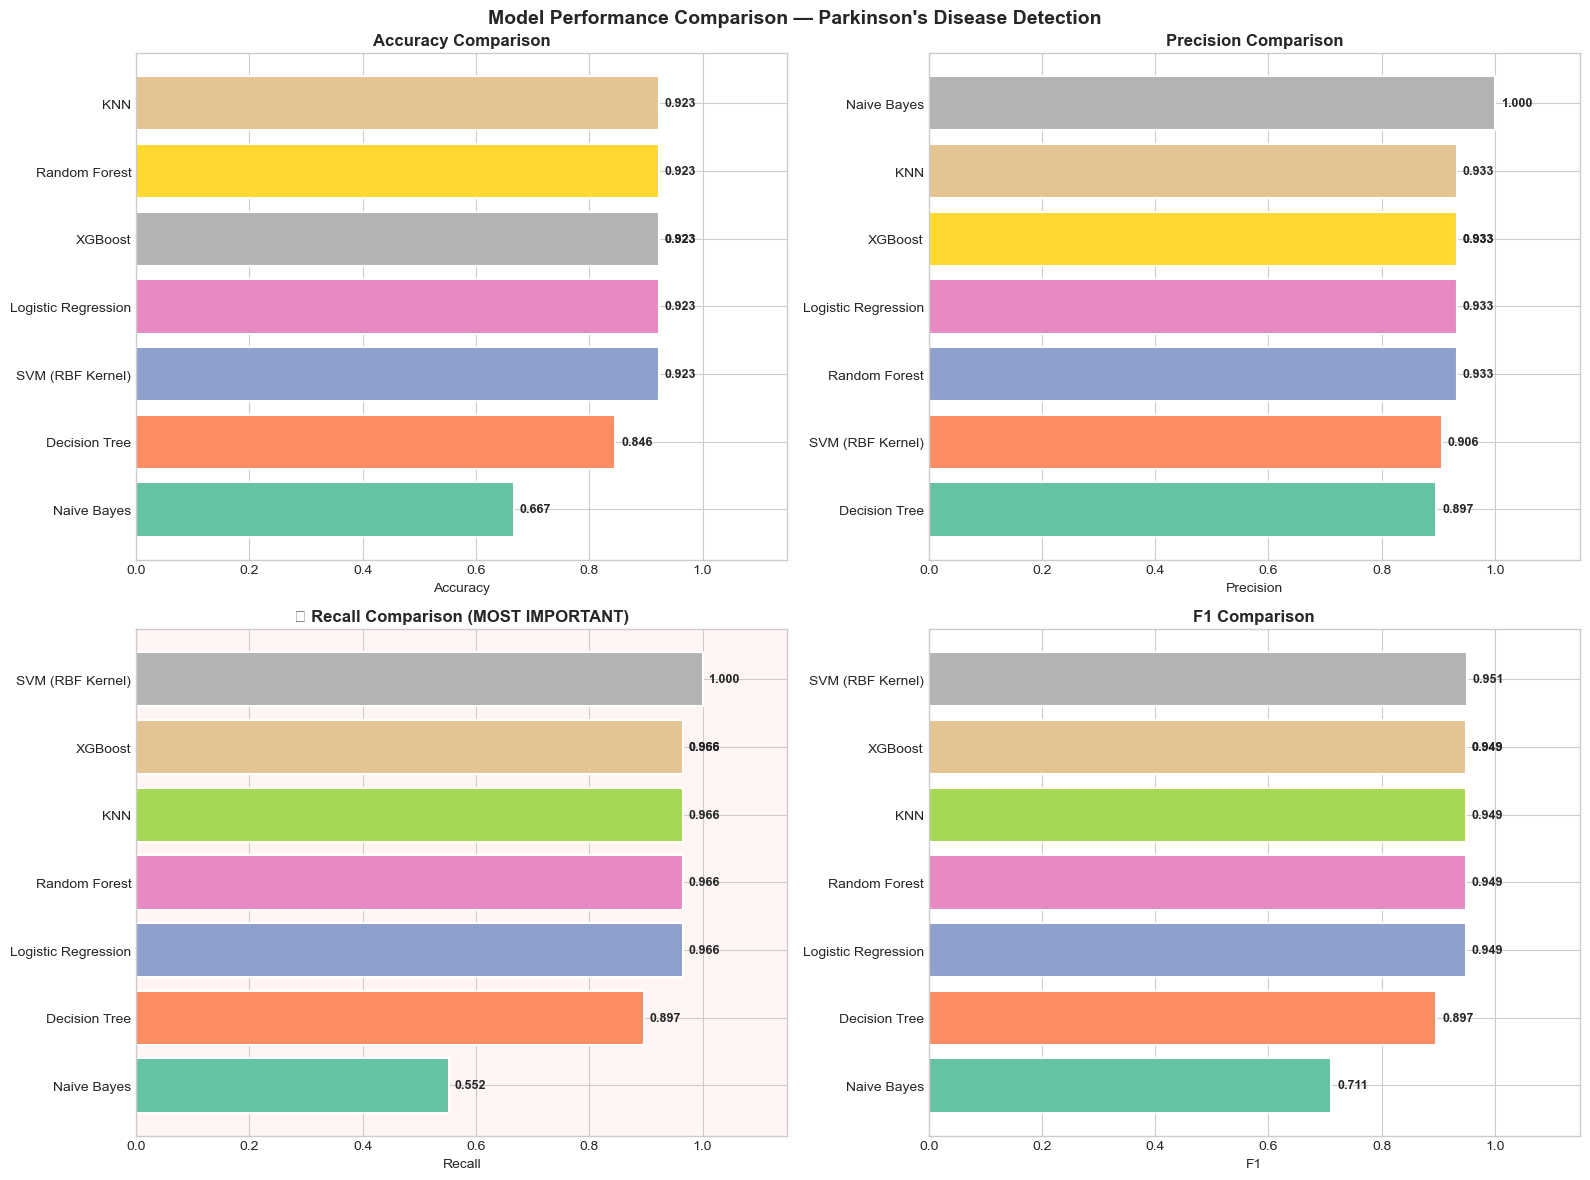

In [42]:
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1']
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
colors = plt.cm.Set2(np.linspace(0, 1, len(results_df)))

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 2, idx % 2]
    sorted_df = results_df.sort_values(metric, ascending=True)
    bars = ax.barh(sorted_df['Model'], sorted_df[metric],
                    color=colors, edgecolor='white', linewidth=1.5)
    ax.set_xlim(0, 1.15)
    ax.set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
    ax.set_xlabel(metric)
    for bar, val in zip(bars, sorted_df[metric]):
        ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2.,
                f'{val:.3f}', va='center', fontsize=9, fontweight='bold')
    if metric == 'Recall':
        ax.set_facecolor('#FFF5F5')
        ax.set_title('⭐ Recall Comparison (MOST IMPORTANT)',
                     fontsize=12, fontweight='bold')

plt.suptitle("Model Performance Comparison — Parkinson's Disease Detection",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/model_comparison_chart.png', dpi=150, bbox_inches='tight')
plt.show()

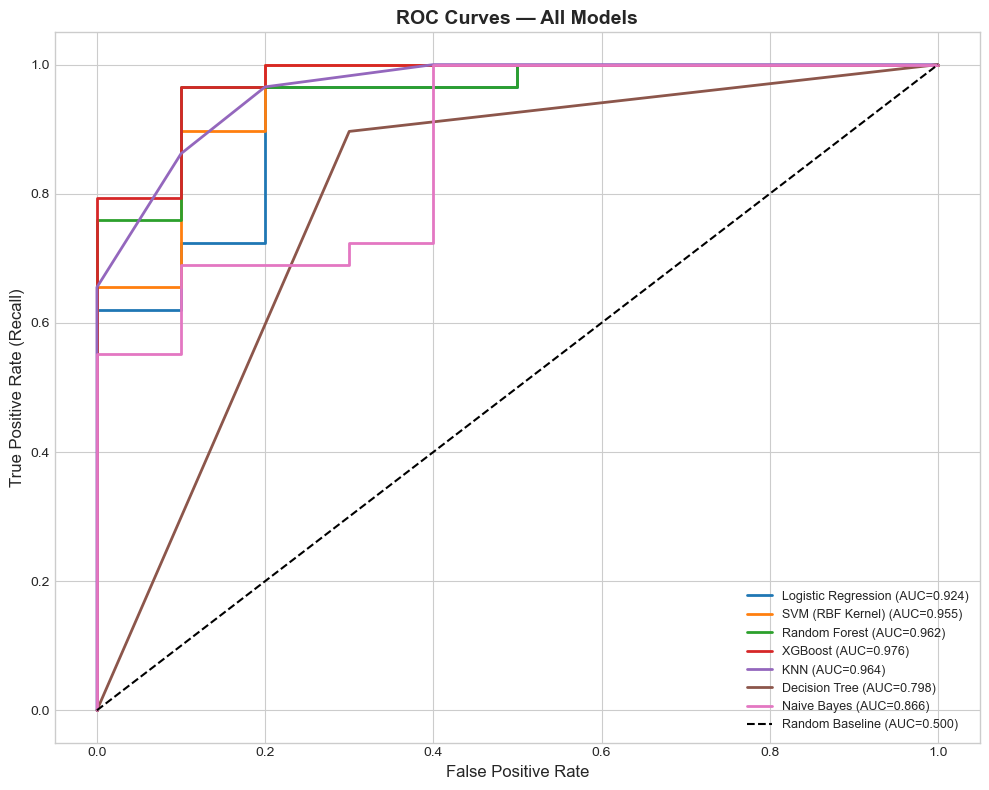

✅ All trained models saved to ../results/trained_models.pkl


In [43]:
plt.figure(figsize=(10, 8))

for model_name, model in trained_models.items():
    try:
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc = roc_auc_score(y_test, y_prob)
        plt.plot(fpr, tpr, linewidth=2,
                 label=f'{model_name} (AUC={auc:.3f})')
    except:
        pass

plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5,
         label='Random Baseline (AUC=0.500)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('../results/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Save all trained models
with open('../results/trained_models.pkl', 'wb') as f:
    pickle.dump(trained_models, f)

print('✅ All trained models saved to ../results/trained_models.pkl')